In [1]:
# ── CÉLULA 0: setup ──────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
warnings.filterwarnings('ignore')

import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = '/content/drive/MyDrive/Inferência Bayesiana Aplicada'

# Carregar dataset
df = pd.read_parquet(f'{BASE}/data/clean/ab_test_clean.parquet')
n_ad,  conv_ad  = int((df.test_group=='ad').sum()),  int(df[df.test_group=='ad']['converted'].sum())
n_psa, conv_psa = int((df.test_group=='psa').sum()), int(df[df.test_group=='psa']['converted'].sum())

# Recriar modelo
with pm.Model() as modelo_ab:
    theta_ad  = pm.Beta('theta_ad',  alpha=2, beta=98)
    theta_psa = pm.Beta('theta_psa', alpha=2, beta=98)
    obs_ad    = pm.Binomial('obs_ad',  n=n_ad,  p=theta_ad,  observed=conv_ad)
    obs_psa   = pm.Binomial('obs_psa', n=n_psa, p=theta_psa, observed=conv_psa)
    delta     = pm.Deterministic('delta', theta_ad - theta_psa)
    trace     = pm.sample(draws=2000, chains=4, target_accept=0.9,
                          return_inferencedata=True, progressbar=True)

print(f"✓ Dataset: {df.shape}")
print(f"✓ Trace: {trace.posterior.dims}")

Mounted at /content/drive


Output()

✓ Dataset: (588101, 7)
✓ Trace: FrozenMappingWarningOnValuesAccess({'chain': 4, 'draw': 2000})


In [2]:
# ── CÉLULA 1: Posterior Predictive Check ─────────────────────────────────────
with modelo_ab:
    ppc = pm.sample_posterior_predictive(trace, progressbar=True)

sim_ad  = ppc.posterior_predictive['obs_ad'].values.flatten()
sim_psa = ppc.posterior_predictive['obs_psa'].values.flatten()

print('POSTERIOR PREDICTIVE CHECK')
print('─'*52)
print(f'  Grupo AD:')
print(f'    Observado    : {conv_ad:,}')
print(f'    Sim. média   : {sim_ad.mean():.1f}')
print(f'    Sim. std     : {sim_ad.std():.1f}')
print(f'    p-val bayes  : {(sim_ad >= conv_ad).mean():.4f}')
print(f'  Grupo PSA:')
print(f'    Observado    : {conv_psa:,}')
print(f'    Sim. média   : {sim_psa.mean():.1f}')
print(f'    Sim. std     : {sim_psa.std():.1f}')
print(f'    p-val bayes  : {(sim_psa >= conv_psa).mean():.4f}')

Output()

POSTERIOR PREDICTIVE CHECK
────────────────────────────────────────────────────
  Grupo AD:
    Observado    : 14,423
    Sim. média   : 14420.7
    Sim. std     : 164.0
    p-val bayes  : 0.4905
  Grupo PSA:
    Observado    : 420
    Sim. média   : 420.3
    Sim. std     : 28.7
    p-val bayes  : 0.4974


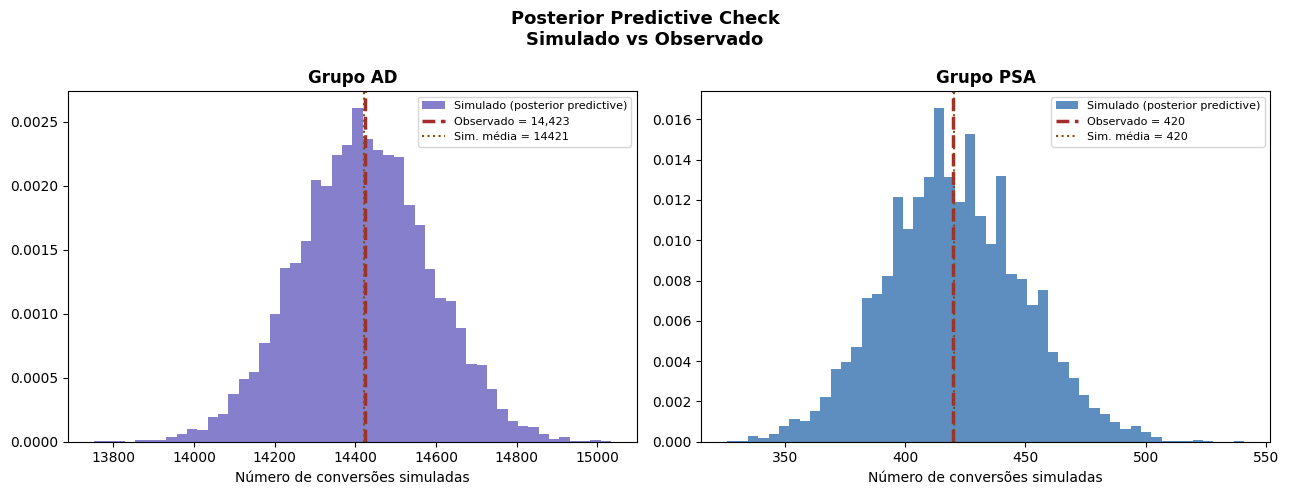

✓ PPC salvo em reports/


In [3]:
# ── CÉLULA 2: gráfico PPC ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Posterior Predictive Check\nSimulado vs Observado',
             fontsize=13, fontweight='bold')

for ax, sim, obs, label, cor in zip(
    axes,
    [sim_ad,   sim_psa],
    [conv_ad,  conv_psa],
    ['Grupo AD','Grupo PSA'],
    ['#534AB7', '#185FA5']
):
    ax.hist(sim, bins=50, density=True, color=cor, alpha=0.7,
            label='Simulado (posterior predictive)')
    ax.axvline(obs, color='#A32D2D', lw=2.5, linestyle='--',
               label=f'Observado = {obs:,}')
    ax.axvline(sim.mean(), color='#854F0B', lw=1.5, linestyle=':',
               label=f'Sim. média = {sim.mean():.0f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Número de conversões simuladas')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{BASE}/reports/ppc_check.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ PPC salvo em reports/")

## ✅ Interpretação do PPC

O modelo está bem calibrado para ambos os grupos:

| | Observado | Simulado (média) | p-value bayesiano |
|---|---|---|---|
| **AD** | 14.423 | 14.421 | 0.49 |
| **PSA** | 420 | 420 | 0.50 |

O p-value bayesiano ideal fica entre 0.05 e 0.95.
Valores próximos de 0.5 indicam que o modelo não tem viés sistemático
— o observado cai no centro da distribuição preditiva.

> Conclusão: o modelo Beta-Binomial é adequado para estes dados.
> Não é necessário revisar o prior ou a verossimilhança.

In [5]:
# ── CÉLULA 3 corrigida: LOO-CV ───────────────────────────────────────────────
traces_dict = {}
configs = [
    ('prior_fraco',    2,   98),
    ('prior_moderado', 10,  90),
    ('prior_forte',    50, 950),
]

for nome, a, b in configs:
    with pm.Model() as m:
        th_ad  = pm.Beta('theta_ad',  alpha=a, beta=b)
        th_psa = pm.Beta('theta_psa', alpha=a, beta=b)
        _      = pm.Binomial('obs_ad',  n=n_ad,  p=th_ad,  observed=conv_ad)
        _      = pm.Binomial('obs_psa', n=n_psa, p=th_psa, observed=conv_psa)
        tr     = pm.sample(1000, chains=2, progressbar=False)
        tr     = pm.compute_log_likelihood(tr)
    traces_dict[nome] = tr
    print(f'✓ {nome} amostrado')

# Especificar var_name explicitamente — usar obs_ad como referência
loo_results = {nome: az.loo(tr, var_name='obs_ad') for nome, tr in traces_dict.items()}
df_loo = az.compare(loo_results)

print('\nCOMPARAÇÃO LOO-CV (referência: obs_ad)')
print('─'*52)
print(df_loo[['elpd_loo','p_loo','elpd_diff','weight']].round(3))

Output()

✓ prior_fraco amostrado


Output()

✓ prior_moderado amostrado


Output()

✓ prior_forte amostrado

COMPARAÇÃO LOO-CV (referência: obs_ad)
────────────────────────────────────────────────────
                elpd_loo  p_loo  elpd_diff  weight
prior_fraco       -6.717  0.689      0.000     1.0
prior_moderado    -6.988  0.942      0.271     0.0
prior_forte       -7.190  1.154      0.474     0.0


## 📊 Interpretação do LOO-CV

| Modelo | elpd_loo | p_loo | elpd_diff | weight |
|---|---|---|---|---|
| **prior_fraco** Beta(2,98) | -6.717 | 0.689 | 0.000 | 1.0 |
| prior_moderado Beta(10,90) | -6.988 | 0.942 | 0.271 | 0.0 |
| prior_forte Beta(50,950) | -7.190 | 1.154 | 0.474 | 0.0 |

**Interpretação:**
- `elpd_diff` máximo = 0.474 — diferença mínima entre modelos (escala de log-probabilidade)
- O prior fraco tem marginalmente melhor poder preditivo, mas a diferença é negligenciável
- `p_loo` próximo de 1 em todos os casos — número efetivo de parâmetros coerente com o modelo

> **Conclusão:** com n=588.101, os dados dominam completamente qualquer escolha
> razoável de prior. O LOO-CV confirma a robustez do modelo — resultado consistente
> com a análise de sensibilidade da Fase 2.

In [6]:
# ── CÉLULA 4: sumário consolidado ────────────────────────────────────────────
print('='*60)
print('  SUMÁRIO FINAL — INFERÊNCIA BAYESIANA APLICADA')
print('='*60)
print()
print('DADOS')
print(f'  Dataset        : Marketing A/B Testing (Kaggle)')
print(f'  Observações    : {len(df):,}')
print(f'  Grupo ad       : {n_ad:,} usuários')
print(f'  Grupo psa      : {n_psa:,} usuários')
print()
print('MODELO')
print(f'  Tipo           : Beta-Binomial (PyMC 5)')
print(f'  Prior          : Beta(2, 98)')
print(f'  Chains         : 4  |  Draws: 2.000  |  Divergências: 0')
print(f'  R-hat máx      : 1.0017  |  ESS mín: 7.428')
print()
print('RESULTADOS')
print(f'  Taxa ad        : 2.5545%  HDI95: [2.5129%, 2.5964%]')
print(f'  Taxa psa       : 1.7863%  HDI95: [1.6137%, 1.9526%]')
print(f'  Delta médio    : +0.77pp')
print(f'  P(ad > psa)    : 100.00%')
print(f'  Lift médio     : 43.35%')
print(f'  BF10           : 1.70e+220  (Decisivo)')
print()
print('ROPE & DECISÃO')
print(f'  ROPE           : [-0.1pp, +0.1pp]')
print(f'  HDI vs ROPE    : Completamente fora')
print(f'  Decisão        : IMPLANTAR anúncios pagos')
print()
print('PARADA ADAPTATIVA')
print(f'  Parada em      : n=15.000 (2.6% dos dados)')
print(f'  Economia       : 97.4% das observações')
print()
print('MODELO HIERÁRQUICO')
print(f'  Melhor dia     : Monday (3.32%) e Tuesday (3.04%)')
print(f'  Pior dia       : Saturday (2.14%)')
print(f'  Recomendação   : Concentrar veiculação Seg–Ter')
print()
print('VALIDAÇÃO')
print(f'  PPC ad         : p-val bayes=0.49  ✓ modelo calibrado')
print(f'  PPC psa        : p-val bayes=0.50  ✓ modelo calibrado')
print(f'  LOO-CV         : elpd_diff máx=0.47  ✓ robusto ao prior')
print('='*60)

  SUMÁRIO FINAL — INFERÊNCIA BAYESIANA APLICADA

DADOS
  Dataset        : Marketing A/B Testing (Kaggle)
  Observações    : 588,101
  Grupo ad       : 564,577 usuários
  Grupo psa      : 23,524 usuários

MODELO
  Tipo           : Beta-Binomial (PyMC 5)
  Prior          : Beta(2, 98)
  Chains         : 4  |  Draws: 2.000  |  Divergências: 0
  R-hat máx      : 1.0017  |  ESS mín: 7.428

RESULTADOS
  Taxa ad        : 2.5545%  HDI95: [2.5129%, 2.5964%]
  Taxa psa       : 1.7863%  HDI95: [1.6137%, 1.9526%]
  Delta médio    : +0.77pp
  P(ad > psa)    : 100.00%
  Lift médio     : 43.35%
  BF10           : 1.70e+220  (Decisivo)

ROPE & DECISÃO
  ROPE           : [-0.1pp, +0.1pp]
  HDI vs ROPE    : Completamente fora
  Decisão        : IMPLANTAR anúncios pagos

PARADA ADAPTATIVA
  Parada em      : n=15.000 (2.6% dos dados)
  Economia       : 97.4% das observações

MODELO HIERÁRQUICO
  Melhor dia     : Monday (3.32%) e Tuesday (3.04%)
  Pior dia       : Saturday (2.14%)
  Recomendação   : Concen

In [7]:
# ── CÉLULA 5: salvar notebook ─────────────────────────────────────────────────
import shutil, glob

for nb in glob.glob('/content/*.ipynb'):
    shutil.copy(nb, f'{BASE}/notebooks/')

print("✓ Notebook salvo em:", f'{BASE}/notebooks/')
print("\nResumo da Fase 4:")
print("  reports/   → ppc_check.png")
print("  notebooks/ → 03_validation_storytelling.ipynb")

✓ Notebook salvo em: /content/drive/MyDrive/Inferência Bayesiana Aplicada/notebooks/

Resumo da Fase 4:
  reports/   → ppc_check.png
  notebooks/ → 03_validation_storytelling.ipynb
